#Data Loading and Cleaning

In [ ]:
# mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

# loading dataset directly from Google Sheets as CSV using the sheet’s share-to-anyone link
import pandas as pd

sheet_url = "https://docs.google.com/spreadsheets/d/1JX1jGywSu3rCuY49WWNet-723tGlYsdS/export?format=csv"
df = pd.read_csv(sheet_url)

df.head(10)


Mounted at /content/drive


,Country,Indicator,Source,Unit,Currency,Frequency,Country Code,Time,Amount
0,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2007-01-01,-56213
1,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2008-01-01,-67563
2,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2009-01-01,-72379
3,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2010-01-01,-98886
4,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2011-01-01,-134138
5,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2012-01-01,-165689
6,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2013-01-01,-246853
7,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2014-01-01,-254715
8,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2015-01-01,-284314
9,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2016-01-01,NaN


In [ ]:
# checking the overall shape of the dataset
# this tells me how many total rows and columns I am working with
print("Shape:", df.shape)

# listing out all the column names so I know exactly what fields exist
print("\nColumn names:", df.columns.tolist())

# getting a complete summary of the dataframe
# this helps me see datatypes, missing values, and any formatting issues
df.info()


Shape: (23784, 9)

Column names: ['Country', 'Indicator', 'Source', 'Unit', 'Currency', 'Frequency', 'Country Code', 'Time', 'Amount']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23784 entries, 0 to 23783
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       23784 non-null  object
 1   Indicator     23784 non-null  object
 2   Source        23784 non-null  object
 3   Unit          23762 non-null  object
 4   Currency      13281 non-null  object
 5   Frequency     23784 non-null  object
 6   Country Code  23784 non-null  object
 7   Time          23780 non-null  object
 8   Amount        23725 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB


In [ ]:
# cleaning and standardising column names
# converting everything to lowercase and replacing spaces with underscores
# this makes the dataframe easier to work with and avoids errors when referencing columns
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# converting the time column into a proper datetime format
# this allows me to sort by year, filter by time, and create time series charts later
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# converting amount to numeric so calculations, plots, and groupby stats work properly
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

# taking a quick look at the first few rows after cleaning
df.head(8)


,country,indicator,source,unit,currency,frequency,country_code,time,amount
0,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2007-01-01,-56213.0
1,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2008-01-01,-67563.0
2,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2009-01-01,-72379.0
3,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2010-01-01,-98886.0
4,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2011-01-01,-134138.0
5,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2012-01-01,-165689.0
6,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2013-01-01,-246853.0
7,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2014-01-01,-254715.0


In [ ]:
# checking how many missing values exist in each column
# sorting them helps me see the worst affected columns first
missing = df.isnull().sum().sort_values(ascending=False)

# displaying only the columns that actually have missing values
missing[missing > 0]


,0
currency,10503
amount,502
unit,22
time,4


In [ ]:
# checking how many unique countries are represented in the dataset
print("Number of countries:", df['country'].nunique())

# showing the first few names just to confirm everything looks correct
print(df['country'].unique())

# checking how many unique indicators exist
print("\nNumber of indicators:", df['indicator'].nunique())

# previewing the first few indicator names to get a sense of the dataset's richness
print(df['indicator'].unique())


Number of countries: 14
['Egypt' 'Ethiopia' 'Ghana' 'Ivory Coast' 'Nigeria' 'South Africa'
 'Tanzania' 'Togo' 'Senegal' 'Kenya' 'Rwanda' 'Algeria' 'Angola'
 'Botswana']

Number of indicators: 27
['Budget Deficit/Surplus' 'Capital Expenditure'
 'Consumer Price Index (CPI)' 'Defence Expenditure'
 'Education Expenditure' 'Expenditure' 'Exports' 'Food Inflation '
 'Food Inflation YoY' 'GDP Growth Rate' 'GDP per Capita' 'GDP per capita'
 'GDP per Capita ' 'Government Debt' 'Health Expenditure' 'Imports'
 'Inflation Rate' 'Inflation Rate ' 'Interest Rate' 'Labour Force'
 'Nominal GDP' 'Population' 'Real GDP' 'Revenue' 'Tax Revenue'
 'Unemployment Rate' 'Value Added Tax (VAT)']


In [ ]:
# checking the earliest and latest dates in the time column
# this tells me how far back the data goes and how recent it is
df['time'].min(), df['time'].max()


(Timestamp('1960-01-01 00:00:00'), Timestamp('2025-09-01 00:00:00'))

In [ ]:
# dropping any fully empty rows just to keep the dataset clean
df = df.dropna(how='all')

# dropping rows missing country, indicator, time, or amount
# these rows cannot be used in analysis
df = df.dropna(subset=['country', 'indicator', 'time', 'amount'])

# checking final shape
df.shape


(23278, 9)

In [ ]:
# checking the cleaned dataframe info
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 23278 entries, 0 to 23783
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   country       23278 non-null  object        
 1   indicator     23278 non-null  object        
 2   source        23278 non-null  object        
 3   unit          23278 non-null  object        
 4   currency      12889 non-null  object        
 5   frequency     23278 non-null  object        
 6   country_code  23278 non-null  object        
 7   time          23278 non-null  datetime64[ns]
 8   amount        23278 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 1.8+ MB


In [ ]:
# creating a mapping of each country to its official currency
currency_map = {
    'Nigeria': 'NGN',
    'Ghana': 'GHS',
    'Ivory Coast': 'XOF',
    'Senegal': 'XOF',
    'Togo': 'XOF',
    'Kenya': 'KES',
    'Tanzania': 'TZS',
    'Ethiopia': 'ETB',
    'Rwanda': 'RWF',
    'Egypt': 'EGP',
    'Algeria': 'DZD',
    'Angola': 'AOA',
    'South Africa': 'ZAR',
    'Botswana': 'BWP'
}

# filling missing currency values based on country
df['currency'] = df.apply(
    lambda row: currency_map[row['country']] if pd.isna(row['currency']) else row['currency'],
    axis=1
)

# checking if any currency is still missing
df['currency'].isna().sum()


np.int64(0)

# Exploratory Data Analysis (EDA)

In [ ]:
# checking how many records exist for each country
# this helps me understand which countries have the strongest coverage
country_counts = df['country'].value_counts()
country_counts


,count
country,
South Africa,5108
Kenya,2900
Nigeria,2849
Ghana,2677
Egypt,1821
Togo,1762
Ivory Coast,1474
Rwanda,1304
Algeria,1209


In [ ]:
# checking how many records exist for each indicator
# this reveals which indicators are the most represented in the dataset
indicator_counts = df['indicator'].value_counts()
indicator_counts


,count
indicator,
Inflation Rate,2868
Consumer Price Index (CPI),2844
Interest Rate,2648
Revenue,1747
Exports,1520
Imports,1512
Budget Deficit/Surplus,1412
Government Debt,1121
Food Inflation,1052


In [ ]:
# generating descriptive statistics for the numeric amount field
# this provides insights into the general scale and spread of fiscal and macroeconomic values
df['amount'].describe()


,amount
count,2.327800e+04
mean,2.899520e+06
std,2.616232e+07
min,-1.350182e+07
25%,8.000000e+00
50%,1.184500e+02
75%,4.998357e+04
max,7.633725e+08


In [ ]:
# checking how many unique years each country has data for
# this helps determine the length of available historical trends
years_per_country = df.groupby('country')['time'].nunique()
years_per_country


,time
country,
Algeria,308
Angola,176
Botswana,138
Egypt,322
Ethiopia,16
Ghana,657
Ivory Coast,394
Kenya,321
Nigeria,251


In [ ]:
# extracting the year component from the datetime field
# this simplifies the time dimension because the dataset is annual, not monthly
df['year'] = df['time'].dt.year

df.head(10)


,country,indicator,source,unit,currency,frequency,country_code,time,amount,year
0,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2007-01-01,-56213.0,2007
1,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2008-01-01,-67563.0,2008
2,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2009-01-01,-72379.0,2009
3,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2010-01-01,-98886.0,2010
4,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2011-01-01,-134138.0,2011
5,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2012-01-01,-165689.0,2012
6,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2013-01-01,-246853.0,2013
7,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2014-01-01,-254715.0,2014
8,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2015-01-01,-284314.0,2015
10,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2017-01-01,-366401.0,2017


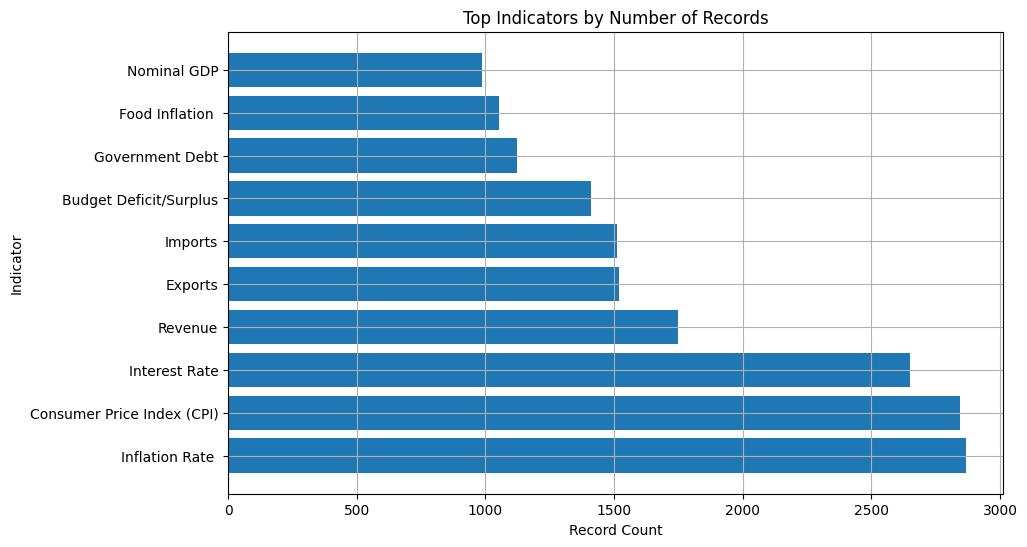

In [ ]:
import matplotlib.pyplot as plt

# counting indicator frequencies
indicator_counts = df['indicator'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(indicator_counts.index, indicator_counts.values)
plt.title('Top Indicators by Number of Records')
plt.xlabel('Record Count')
plt.ylabel('Indicator')
plt.grid(True)
plt.show()


##Frequency Distribution in the data set

In [ ]:
# checking unique frequency types
df['frequency'].unique()

array(['Yearly', 'Monthly', 'Quarterly'], dtype=object)

In [ ]:
df[df['indicator'] == 'Budget Deficit/Surplus'][['country','frequency']].drop_duplicates().sort_values('country')


,country,frequency
0,Egypt,Yearly
86,Ethiopia,Yearly
96,Ghana,Monthly
259,Ivory Coast,Yearly
324,Nigeria,Yearly
338,Nigeria,Monthly
515,Nigeria,Quarterly
1406,Senegal,Yearly
574,South Africa,Monthly
1357,Tanzania,Yearly


In [ ]:
import pandas as pd

# copy original dataset
df2 = df.copy()

# create year column from time field
df2['year'] = pd.to_datetime(df2['time'], errors='coerce').dt.year
df2 = df2.dropna(subset=['year'])
df2['year'] = df2['year'].astype(int)

# define indicator types for aggregation rules
sum_indicators = [
    'Budget Deficit/Surplus', 'Revenue', 'Expenditure', 'Capital Expenditure',
    'Tax Revenue', 'Exports', 'Imports', 'Government Debt'
]

mean_indicators = [
    'Inflation Rate', 'Consumer Price Index (CPI)', 'Interest Rate',
    'GDP Growth Rate', 'Food Inflation', 'Food Inflation YoY',
    'Unemployment Rate'
]

# build annual dataset using different aggregation rules
annual_frames = []

# A. Sum based indicators
annual_sum = df2[df2['indicator'].isin(sum_indicators)].groupby(
    ['country','indicator','year'], as_index=False
).agg({'amount': 'sum'})
annual_frames.append(annual_sum)

# B. Mean based indicators
annual_mean = df2[df2['indicator'].isin(mean_indicators)].groupby(
    ['country','indicator','year'], as_index=False
).agg({'amount': 'mean'})
annual_frames.append(annual_mean)

# C. All other indicators take last available for the year
remaining = df2[~df2['indicator'].isin(sum_indicators + mean_indicators)]

annual_last = remaining.sort_values(['country','indicator','year','time']).groupby(
    ['country','indicator','year'], as_index=False
).agg({'amount': 'last'})
annual_frames.append(annual_last)

# unify final annual dataset
annual_df = pd.concat(annual_frames, ignore_index=True)

# attach metadata columns: unit, currency, source
meta = df2.groupby(['country','indicator','year']).agg({
    'unit': lambda x: x.dropna().iloc[0] if x.dropna().shape[0]>0 else None,
    'currency': lambda x: x.dropna().iloc[0] if x.dropna().shape[0]>0 else None,
    'source': lambda x: x.dropna().iloc[0] if x.dropna().shape[0]>0 else None
}).reset_index()

# merge metadata with final annual dataset
annual_df = annual_df.merge(meta, on=['country','indicator','year'], how='left')

# final check
annual_df.head()


,country,indicator,year,amount,unit,currency,source
0,Algeria,Exports,1977,6.0,Billions,USD,Bank of Algeria
1,Algeria,Exports,1978,6.3,Billions,USD,Bank of Algeria
2,Algeria,Exports,1979,9.5,Billions,USD,Bank of Algeria
3,Algeria,Exports,1980,13.7,Billions,USD,Bank of Algeria
4,Algeria,Exports,1981,14.1,Billions,USD,Bank of Algeria


In [ ]:
# prepare for yearly aggregation
# ensure frequency column is lower case so checks are consistent
df['frequency'] = df['frequency'].astype(str).str.strip().str.lower()

# create a year column if not already present
df['year'] = df['time'].dt.year

# helper function to choose aggregation method based on indicator name
def choose_agg(indicator):
    ind = str(indicator).lower()
    # specific cases first
    if 'gdp per capita' in ind or 'per capita' in ind:
        return 'mean'     # per person measures are averaged across periods
    if 'population' in ind or 'population_total' in ind or 'population ' in ind:
        return 'last'     # population is a stock variable, take end of year value
    if 'government debt' in ind or 'government_debt' in ind or 'debt' in ind:
        return 'last'     # debt is a stock, end of period value is most relevant
    # rate and index style measures are averaged
    rate_terms = ['rate', 'inflation', 'cpi', 'growth rate', 'growth', 'unemployment', 'interest']
    if any(t in ind for t in rate_terms):
        return 'mean'
    # monetary flows and aggregates are summed across periods
    flow_terms = ['revenue', 'exports', 'imports', 'expenditure', 'tax', 'capital', 'gdp', 'budget deficit', 'deficit', 'surplus']
    if any(t in ind for t in flow_terms):
        return 'sum'
    # fallback to mean if uncertain
    return 'mean'

# attach chosen aggregation method to each indicator
indicator_agg_map = {ind: choose_agg(ind) for ind in df['indicator'].unique()}
df['agg_method'] = df['indicator'].map(indicator_agg_map)

# function to aggregate a group for a single country indicator year
import numpy as np

def aggregate_group(g):
    method = g['agg_method'].iat[0]
    values = g['amount'].dropna().astype(float)
    count = len(values)
    if count == 0:
        return pd.Series({'amount_year': np.nan, 'n_periods': 0, 'agg_method': method})
    if method == 'sum':
        return pd.Series({'amount_year': values.sum(), 'n_periods': count, 'agg_method': method})
    if method == 'mean':
        return pd.Series({'amount_year': values.mean(), 'n_periods': count, 'agg_method': method})
    if method == 'last':
        # sort by time and take the last available value in that year
        last_val = g.sort_values('time')['amount'].dropna().astype(float).iloc[-1]
        return pd.Series({'amount_year': last_val, 'n_periods': count, 'agg_method': method})
    # fallback
    return pd.Series({'amount_year': values.mean(), 'n_periods': count, 'agg_method': method})

# apply aggregation across country, indicator, year
yearly = df.groupby(['country', 'indicator', 'year'], as_index=False).apply(aggregate_group).reset_index()

# flatten columns if needed
yearly = yearly.rename(columns={'amount_year': 'amount', 'n_periods': 'n_periods_in_year'})

# check how many original periods contributed to each yearly value
# and flag possible incomplete yearly aggregates
# set a threshold for monthly data requiring at least 6 months to consider the annual aggregation reliable
def flag_incomplete(row):
    # find the typical frequency for that indicator in that country year
    if row['n_periods_in_year'] == 0:
        return 'no_data'
    # if frequency column exists for the group, we could analyse it in detail
    # simple rule: if n_periods_in_year < 3 mark as partial for quarterly or monthly series
    if row['n_periods_in_year'] < 3:
        return 'partial'
    return 'ok'

yearly['aggregation_quality'] = yearly.apply(flag_incomplete, axis=1)

# preview the resulting yearly table
yearly.head(10)


/tmp/ipython-input-4128619520.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly = df.groupby(['country', 'indicator', 'year'], as_index=False).apply(aggregate_group).reset_index()


,index,country,indicator,year,amount,n_periods_in_year,agg_method,aggregation_quality
0,0,Algeria,Consumer Price Index (CPI),2002,101.432500,12,mean,ok
1,1,Algeria,Consumer Price Index (CPI),2003,105.755000,12,mean,ok
2,2,Algeria,Consumer Price Index (CPI),2004,109.951667,12,mean,ok
3,3,Algeria,Consumer Price Index (CPI),2005,111.471667,12,mean,ok
4,4,Algeria,Consumer Price Index (CPI),2006,114.048333,12,mean,ok
5,5,Algeria,Consumer Price Index (CPI),2007,118.244167,12,mean,ok
6,6,Algeria,Consumer Price Index (CPI),2008,123.989167,12,mean,ok
7,7,Algeria,Consumer Price Index (CPI),2009,131.102500,12,mean,ok
8,8,Algeria,Consumer Price Index (CPI),2010,136.230000,12,mean,ok
9,9,Algeria,Consumer Price Index (CPI),2011,142.393333,12,mean,ok


In [ ]:
# summary counts for the quality flag
print("Aggregation quality counts:")
print(yearly['aggregation_quality'].value_counts(), "\n")

Aggregation quality counts:
aggregation_quality
partial    2394
ok         2183
Name: count, dtype: int64 



<Axes: xlabel='year', ylabel='amount'>

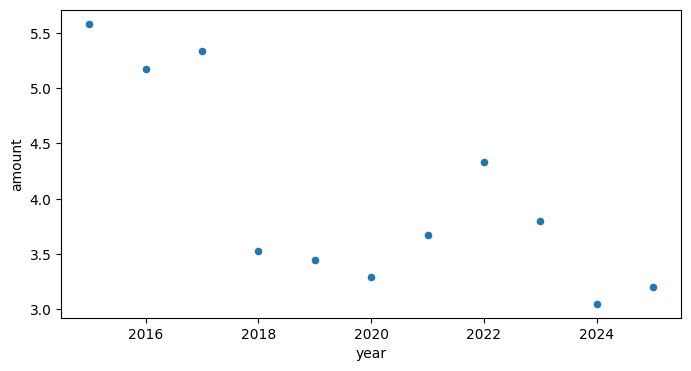

In [ ]:
#confirming Validity of outputs through inflation rate
subset = yearly[yearly['indicator']=='Inflation Rate']
subset.plot(x='year', y='amount', kind='scatter', figsize=(8,4))


In [ ]:
# Time coverage table using the yearly dataset

# create a summary table showing:
# earliest year, latest year, and total number of years for each country
time_coverage = yearly.groupby('country').agg(
    first_year=('year', 'min'),
    last_year=('year', 'max'),
    n_years=('year', 'nunique')
).reset_index()

# sort the table by number of years in descending order to see strongest coverage first
time_coverage = time_coverage.sort_values('n_years', ascending=False)

# display the table
time_coverage


,country,first_year,last_year,n_years
11,South Africa,1960,2025,66
6,Ivory Coast,1960,2025,66
13,Togo,1965,2025,61
5,Ghana,1971,2025,55
0,Algeria,1977,2025,49
8,Nigeria,1981,2025,45
3,Egypt,1982,2025,44
9,Rwanda,1990,2025,36
12,Tanzania,1997,2025,29
7,Kenya,1998,2025,28


In [ ]:
# filtering the yearly dataset to the final analysis window
# the window comes from the time coverage table which shows that all countries overlap from 2014 to 2024

analysis_df = yearly[(yearly['year'] >= 2014) & (yearly['year'] <= 2024)].copy()

# quick check to confirm the filter worked
analysis_df['year'].min(), analysis_df['year'].max(), analysis_df.shape


(2014, 2024, (1901, 8))

In [ ]:
# save the filtered analysis dataset to a CSV file in Colab
analysis_df.to_csv('analysis_df_2014_2024.csv', index=False)

# download the CSV file to your local system
from google.colab import files
files.download('analysis_df_2014_2024.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Analysis

In [ ]:
# Block 1: build the 2014 vs 2024 fiscal table and attach official currency codes

# grab the fiscal balance rows from the analysis dataset
balance_df = analysis_df[analysis_df['indicator'] == 'Budget Deficit/Surplus'].copy()

# pull fiscal values for 2014 and 2024
balance_2014 = balance_df[balance_df['year'] == 2014][['country','amount']].rename(columns={'amount':'deficit_2014'})
balance_2024 = balance_df[balance_df['year'] == 2024][['country','amount']].rename(columns={'amount':'deficit_2024'})

# merge the two endpoint years side by side
table = balance_2014.merge(balance_2024, on='country', how='outer')

# attach the official currency codes using the mapping provided
currency_map = {
    'Nigeria': 'NGN',
    'Ghana': 'GHS',
    'Ivory Coast': 'XOF',
    'Senegal': 'XOF',
    'Togo': 'XOF',
    'Kenya': 'KES',
    'Tanzania': 'TZS',
    'Ethiopia': 'ETB',
    'Rwanda': 'RWF',
    'Egypt': 'EGP',
    'Algeria': 'DZD',
    'Angola': 'AOA',
    'South Africa': 'ZAR',
    'Botswana': 'BWP'
}

# map currencies and create a column
table['currency'] = table['country'].map(currency_map)

# safe percentage change function
import numpy as np
def safe_pct_change(a2014, a2024):
    if pd.isna(a2014) or a2014 == 0:
        return np.nan
    return ((a2024 - a2014) / abs(a2014)) * 100

# compute percent change and tidy the table
table['pct_change'] = table.apply(lambda r: safe_pct_change(r['deficit_2014'], r['deficit_2024']), axis=1)

# final column order and sort by pct_change (worst deterioration first)
final_table = table[['country','currency','deficit_2014','deficit_2024','pct_change']].sort_values('pct_change').reset_index(drop=True)

# show the final table for copy into the report
final_table


,country,currency,deficit_2014,deficit_2024,pct_change
0,Ghana,GHS,-7216.8,-92647.25,-1183.771893
1,Nigeria,NGN,-2506932.0,-25777864.00,-928.263391
2,Ivory Coast,XOF,-376.3,-2120.60,-463.539729
3,Togo,XOF,-74.7,-362.60,-385.408300
4,Senegal,XOF,-354.7,-820.00,-131.181280
5,South Africa,ZAR,-167830.0,-321565.00,-91.601621
6,Egypt,EGP,-887658.0,NaN,NaN
7,Ethiopia,ETB,NaN,-246950.70,NaN
8,Tanzania,TZS,-3775.7,NaN,NaN


In [ ]:
# filter for budget balance only
balance_df = analysis_df[analysis_df['indicator'] == 'Budget Deficit/Surplus'].copy()

# keep only needed columns
balance_df = balance_df[['country', 'year', 'amount']]

# get 2014 values
start_vals = balance_df[balance_df['year'] == 2014].set_index('country')['amount']

# get latest year per country
end_vals = balance_df.groupby('country').apply(lambda x: x.loc[x['year'].idxmax()])
end_vals = end_vals.set_index('country')['amount']

# combine into one clean table
pct_change_table = pd.DataFrame({
    'start_2014': start_vals,
    'end_latest': end_vals
})

# drop countries missing either 2014 or the latest value
pct_change_table = pct_change_table.dropna()

# calculate percentage change from 2014 to latest
pct_change_table['pct_change_2014_to_latest'] = (
    (pct_change_table['end_latest'] - pct_change_table['start_2014'])
    / pct_change_table['start_2014']
) * 100

pct_change_table


/tmp/ipython-input-3390588536.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  end_vals = balance_df.groupby('country').apply(lambda x: x.loc[x['year'].idxmax()])


,start_2014,end_latest,pct_change_2014_to_latest
country,,,
Egypt,-887658.0,-2089639.00,135.410372
Ghana,-7216.8,-92647.25,1183.771893
Ivory Coast,-376.3,-2120.60,463.539729
Nigeria,-2506932.0,-25777864.00,928.263391
Senegal,-354.7,-820.00,131.181280
South Africa,-167830.0,-321565.00,91.601621
Tanzania,-3775.7,-9880.00,161.673332
Togo,-74.7,-362.60,385.408300


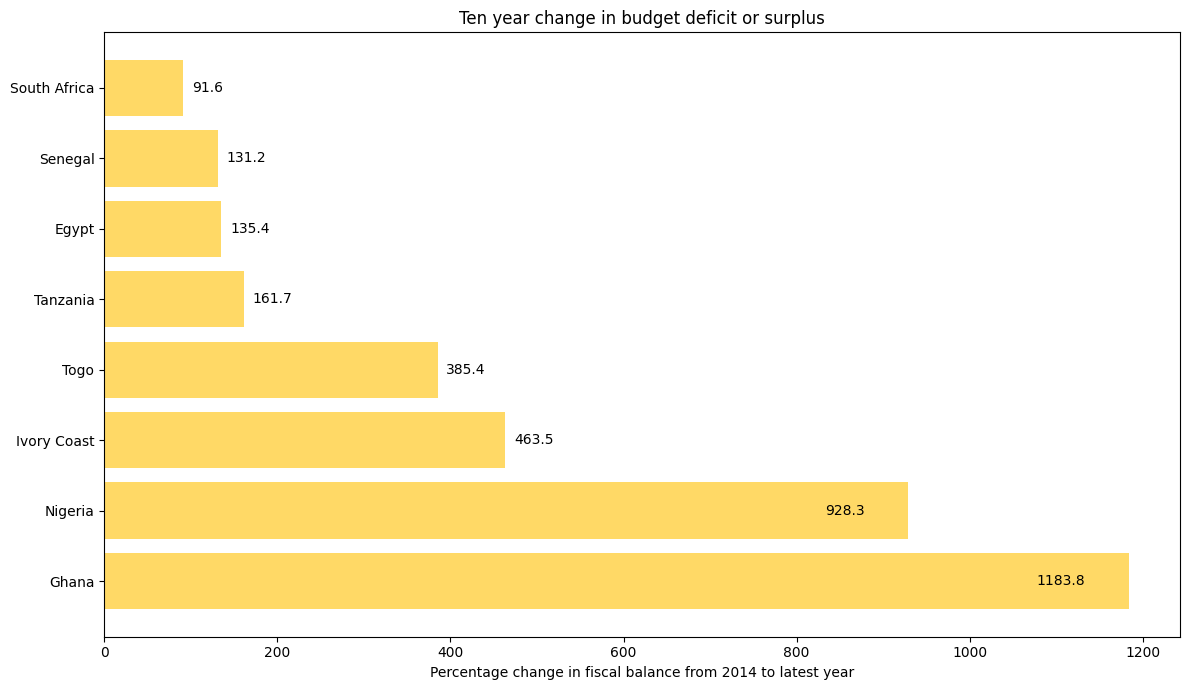

In [ ]:
import matplotlib.pyplot as plt

pct_change_table_sorted = pct_change_table.sort_values(
    'pct_change_2014_to_latest', ascending=False
).copy()

pct_change_table_sorted['pct_change_rounded'] = pct_change_table_sorted[
    'pct_change_2014_to_latest'
].round(1)

plt.figure(figsize=(12,7))

bars = plt.barh(
    pct_change_table_sorted.index,
    pct_change_table_sorted['pct_change_rounded'],
    color='#ffd966'
)

for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2

    label = f"{width:.1f}"

    if width > 600:
        plt.text(
            width - 50,
            y_pos,
            label,
            va='center',
            ha='right',
            color='black',
            fontsize=10
        )
    else:
        plt.text(
            width + 10,
            y_pos,
            label,
            va='center',
            ha='left',
            fontsize=10
        )

plt.xlabel('Percentage change in fiscal balance from 2014 to latest year')
plt.title('Ten year change in budget deficit or surplus')
plt.grid(False)
plt.tight_layout()

plt.show()


In [ ]:
# filter for revenue only
revenue_df = analysis_df[analysis_df['indicator'] == 'Revenue'].copy()

# keep only relevant columns
revenue_df = revenue_df[['country', 'year', 'amount']]

# 2014 revenue values
rev_2014 = revenue_df[revenue_df['year'] == 2014].set_index('country')['amount']

# latest revenue per country
rev_latest = revenue_df.groupby('country').apply(
    lambda x: x.loc[x['year'].idxmax()]
)
rev_latest = rev_latest.set_index('country')['amount']

# combine
revenue_change = pd.DataFrame({
    'rev_2014': rev_2014,
    'rev_latest': rev_latest
}).dropna()

# percentage change
revenue_change['pct_change_revenue'] = (
    (revenue_change['rev_latest'] - revenue_change['rev_2014'])
    / revenue_change['rev_2014']
) * 100

revenue_change


/tmp/ipython-input-2363548567.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rev_latest = revenue_df.groupby('country').apply(


,rev_2014,rev_latest,pct_change_revenue
country,,,
Egypt,1644081.0,4881741.00,196.928254
Ghana,24745.3,186593.25,654.055316
Ivory Coast,3293.3,8775.90,166.477393
Kenya,6239798.2,16779107.60,168.904651
Nigeria,9863313.0,12157582.00,23.260633
Rwanda,903.0,2688.00,197.674419
South Africa,944083.0,1874664.00,98.569829
Tanzania,10182.5,15077437.03,147972.055291
Togo,636.7,1703.60,167.567143


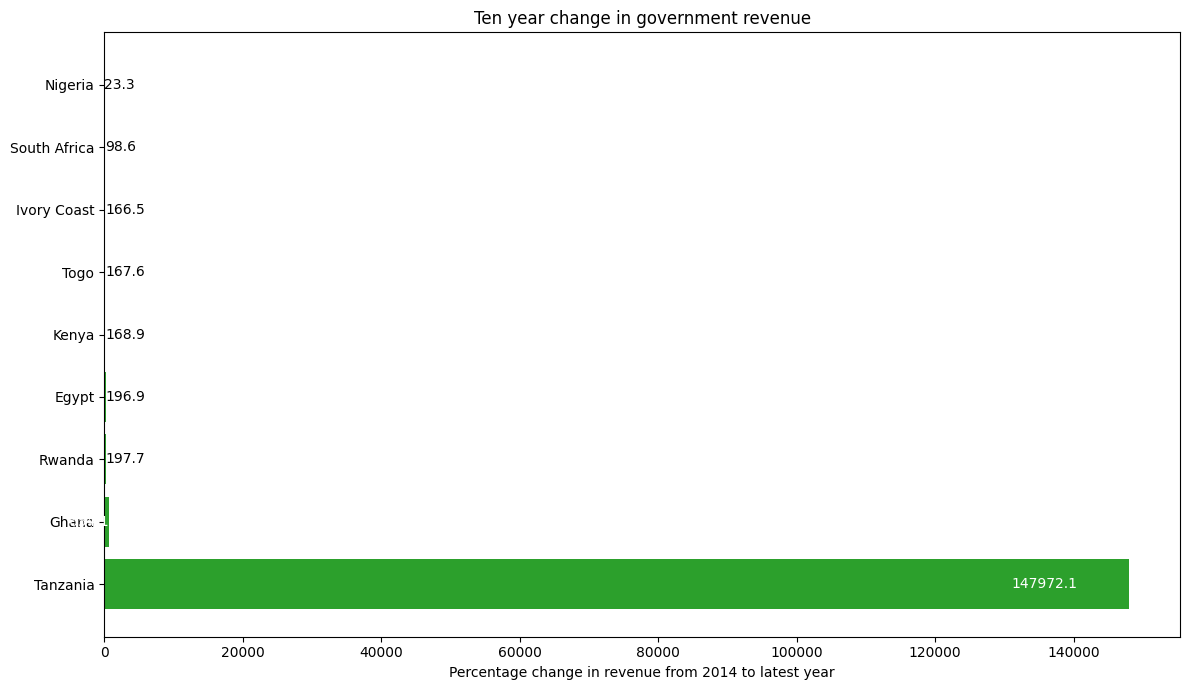

In [ ]:
import matplotlib.pyplot as plt

rev_sorted = revenue_change.sort_values('pct_change_revenue', ascending=False).copy()
rev_sorted['pct_change_rounded'] = rev_sorted['pct_change_revenue'].round(1)

plt.figure(figsize=(12,7))

bars = plt.barh(
    rev_sorted.index,
    rev_sorted['pct_change_rounded'],
    color='tab:green'
)

for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    label = f"{width:.1f}"

    if width > 600:
        plt.text(width - width * 0.05, y_pos, label, ha='right', va='center', color='white')
    else:
        plt.text(width + 10, y_pos, label, ha='left', va='center')

plt.xlabel('Percentage change in revenue from 2014 to latest year')
plt.title('Ten year change in government revenue')
plt.grid(False)
plt.tight_layout()
plt.show()


In [ ]:
# locate Tanzania revenue for 2014 and convert from billions to millions
analysis_df.loc[
    (analysis_df['country'] == 'Tanzania') &
    (analysis_df['indicator'] == 'Revenue') &
    (analysis_df['year'] == 2014),
    'amount'
] = analysis_df.loc[
    (analysis_df['country'] == 'Tanzania') &
    (analysis_df['indicator'] == 'Revenue') &
    (analysis_df['year'] == 2014),
    'amount'
] * 1000


In [ ]:
# filter for revenue only
revenue_df = analysis_df[analysis_df['indicator'] == 'Revenue'].copy()

revenue_df = revenue_df[['country', 'year', 'amount']]

rev_2014 = revenue_df[revenue_df['year'] == 2014].set_index('country')['amount']

rev_latest = revenue_df.groupby('country').apply(
    lambda x: x.loc[x['year'].idxmax()]
)
rev_latest = rev_latest.set_index('country')['amount']

revenue_change = pd.DataFrame({
    'rev_2014': rev_2014,
    'rev_latest': rev_latest
}).dropna()

revenue_change['pct_change_revenue'] = (
    (revenue_change['rev_latest'] - revenue_change['rev_2014'])
    / revenue_change['rev_2014']
) * 100

revenue_change


/tmp/ipython-input-3316323911.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rev_latest = revenue_df.groupby('country').apply(


,rev_2014,rev_latest,pct_change_revenue
country,,,
Egypt,1644081.0,4881741.00,196.928254
Ghana,24745.3,186593.25,654.055316
Ivory Coast,3293.3,8775.90,166.477393
Kenya,6239798.2,16779107.60,168.904651
Nigeria,9863313.0,12157582.00,23.260633
Rwanda,903.0,2688.00,197.674419
South Africa,944083.0,1874664.00,98.569829
Tanzania,10182500.0,15077437.03,48.072055
Togo,636.7,1703.60,167.567143


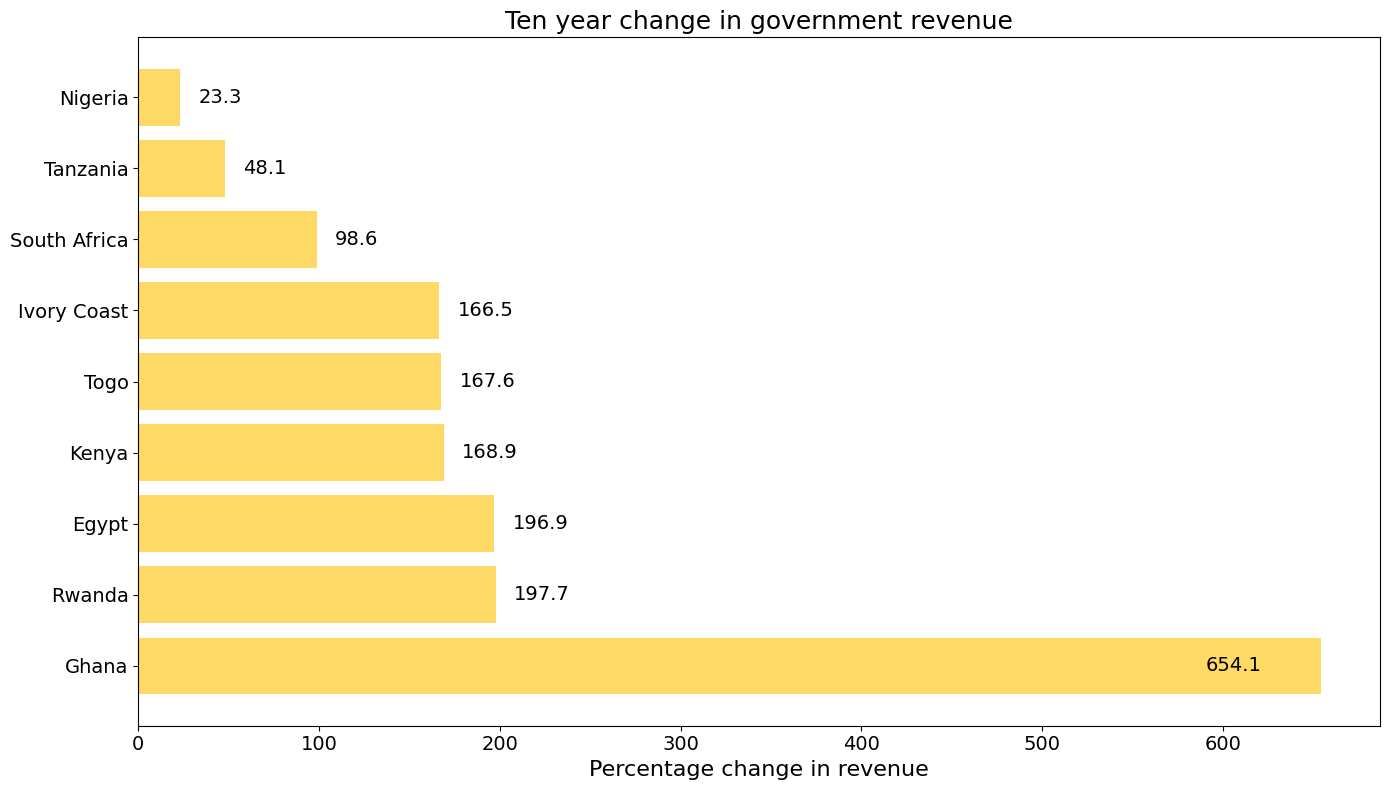

In [ ]:
import matplotlib.pyplot as plt

# Sort and round values
rev_sorted = revenue_change.sort_values('pct_change_revenue', ascending=False).copy()
rev_sorted['pct_change_rounded'] = rev_sorted['pct_change_revenue'].round(1)

# Transparent figure and axes
fig = plt.figure(figsize=(14,8), facecolor='none')
ax = fig.add_subplot(111)
ax.set_facecolor('none')

# Bar chart
bars = ax.barh(
    rev_sorted.index,
    rev_sorted['pct_change_rounded'],
    color='#ffd966'
)

# Data labels with larger font
for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    label = f"{width:.1f}"

    if width > 600:
        ax.text(
            width - width * 0.05,
            y_pos,
            label,
            ha='right',
            va='center',
            fontsize=14,
            color='black'
        )
    else:
        ax.text(
            width + 10,
            y_pos,
            label,
            ha='left',
            va='center',
            fontsize=14,
            color='black'
        )

# Bigger axis label and title
ax.set_xlabel(
    'Percentage change in revenue',
    fontsize=16
)
ax.set_title(
    'Ten year change in government revenue',
    fontsize=18
)

# Bigger tick labels
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

# Clean chart
ax.grid(False)
plt.tight_layout()

# Save crisp versions
plt.savefig("ten_year_revenue.png", dpi=300, transparent=True, bbox_inches='tight')
plt.savefig("ten_year_revenue.svg", transparent=True, bbox_inches='tight')

plt.show()


/tmp/ipython-input-3890915350.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exp_latest = exp_df.groupby('country').apply(lambda x: x.loc[x['year'].idxmax()])


,exp_2014,exp_latest,pct_change_expenditure
country,,,
Ghana,31962.40,226243.54,607.843
Nigeria,12370245.00,37935446.00,206.667
Ivory Coast,3669.60,10896.50,196.940
Kenya,7474051.70,21461216.00,187.143
Egypt,2475498.00,6975748.00,181.792
Togo,636.70,1703.60,167.567
Tanzania,13958.20,36157.00,159.038
Senegal,2468.30,4920.00,99.327
Rwanda,1653.87,3294.63,99.207


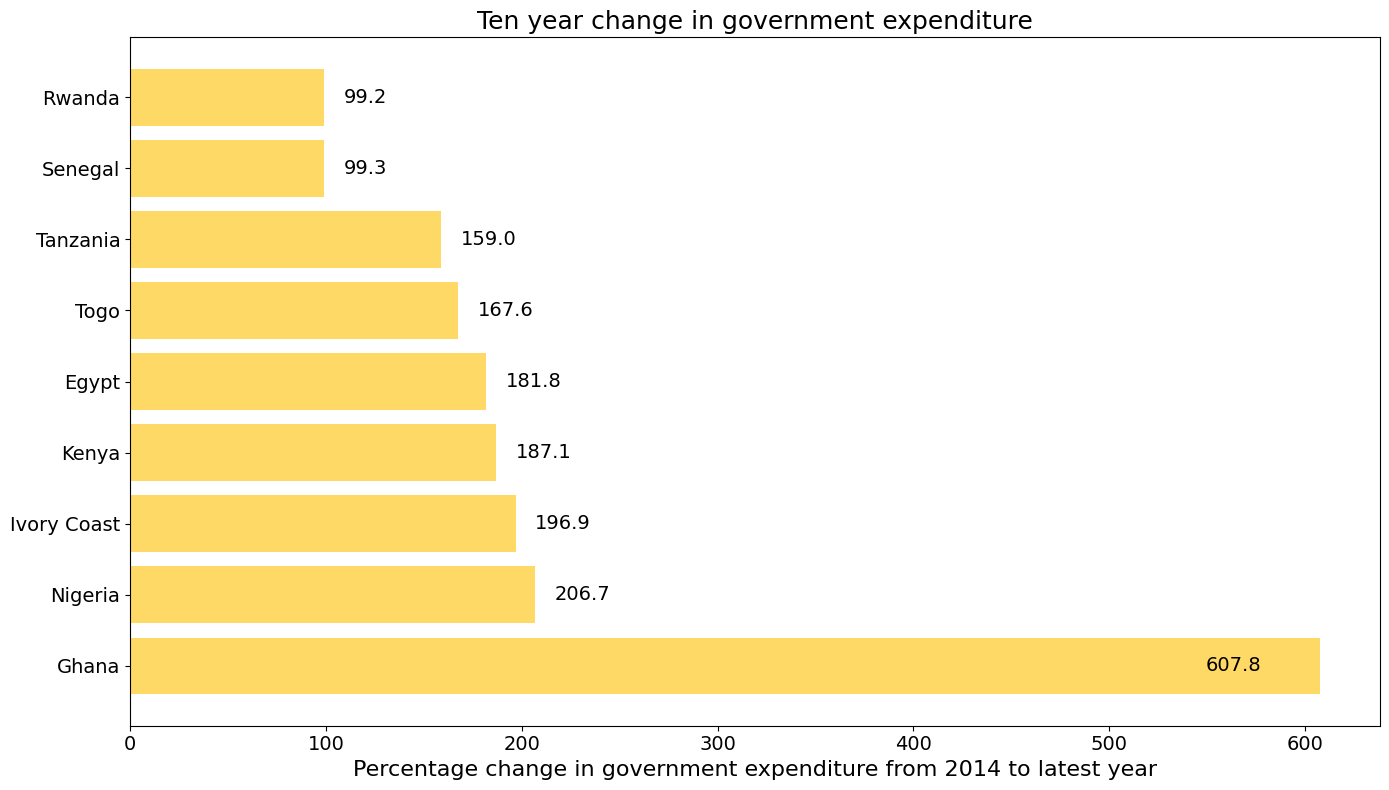

Saved expenditure_change_2014_to_latest.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

# ---------- Prepare table ----------

# 1. Build the expenditure start / end table and pct change
exp_df = analysis_df[analysis_df['indicator'] == 'Expenditure'][['country','year','amount']].copy()

# get 2014 and latest per country
exp_2014 = exp_df[exp_df['year'] == 2014].set_index('country')['amount']
exp_latest = exp_df.groupby('country').apply(lambda x: x.loc[x['year'].idxmax()])
exp_latest = exp_latest.set_index('country')['amount']

exp_change = pd.DataFrame({
    'exp_2014': exp_2014,
    'exp_latest': exp_latest
}).dropna()

# 2. Basic sanity check for unit/scale problems
# If the ratio of latest/start is > 1000 or < 0.001 mark as suspicious
exp_change['ratio'] = exp_change['exp_latest'] / exp_change['exp_2014']
exp_change['suspicious'] = exp_change['ratio'].apply(lambda r: True if (r > 1000 or r < 0.001) else False)

# 3. compute percent change
exp_change['pct_change_expenditure'] = ((exp_change['exp_latest'] - exp_change['exp_2014']) / exp_change['exp_2014']) * 100
exp_change = exp_change.sort_values('pct_change_expenditure', ascending=False)

# 4. print suspicious rows first if any
suspicious_rows = exp_change[exp_change['suspicious']]
if not suspicious_rows.empty:
    print("Warning: suspicious scale changes detected for these countries. Inspect raw units and values before final interpretation.\n")
    display(suspicious_rows[['exp_2014','exp_latest','ratio','pct_change_expenditure']].round(3))

# 5. show the clean table
display(exp_change[['exp_2014','exp_latest','pct_change_expenditure']].round(3))

# ---------- Plot with improved styling ----------

exp_plot = exp_change.copy()
exp_plot['pct_round'] = exp_plot['pct_change_expenditure'].round(1)

# Transparent figure and axes with larger sizes
fig = plt.figure(figsize=(14,8), facecolor='none')
ax = fig.add_subplot(111)
ax.set_facecolor('none')

bars = ax.barh(exp_plot.index, exp_plot['pct_round'], color='#ffd966')

# Larger data labels
for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    label = f"{width:.1f}"
    if abs(width) > 600:
        # put label inside bar for very large values
        ax.text(width - abs(width) * 0.05, y_pos, label, ha='right', va='center', fontsize=14, color='black')
    else:
        ax.text(width + 10, y_pos, label, ha='left', va='center', fontsize=14, color='black')

# Larger title and labels
ax.set_xlabel('Percentage change in government expenditure from 2014 to latest year', fontsize=16)
ax.set_title('Ten year change in government expenditure', fontsize=18)

# Bigger tick labels
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

# Remove grid and tighten layout
ax.grid(False)
plt.tight_layout()

# Save crisp transparent versions
plt.savefig("ten_year_expenditure.png", dpi=300, transparent=True, bbox_inches='tight')
plt.savefig("ten_year_expenditure.svg", transparent=True, bbox_inches='tight')

plt.show()

# 7. Save table for record
exp_change.to_csv('expenditure_change_2014_to_latest.csv', index=True)
print("Saved expenditure_change_2014_to_latest.csv")


In [ ]:
# combine revenue and expenditure tables
rev_exp_compare = pd.concat([
    revenue_change['pct_change_revenue'],
    exp_change['pct_change_expenditure']
], axis=1, join='inner')

rev_exp_compare.columns = ['revenue_pct_change', 'expenditure_pct_change']

# calculate the gap
rev_exp_compare['exp_minus_rev'] = (
    rev_exp_compare['expenditure_pct_change'] -
    rev_exp_compare['revenue_pct_change']
)

rev_exp_compare.sort_values('exp_minus_rev', ascending=False)


,revenue_pct_change,expenditure_pct_change,exp_minus_rev
country,,,
Nigeria,23.260633,206.666893,183.406260
Tanzania,48.072055,159.037698,110.965643
Ivory Coast,166.477393,196.939721,30.462327
Kenya,168.904651,187.142996,18.238345
Togo,167.567143,167.567143,0.000000
Egypt,196.928254,181.791704,-15.136549
Ghana,654.055316,607.842778,-46.212538
Rwanda,197.674419,99.207314,-98.467105


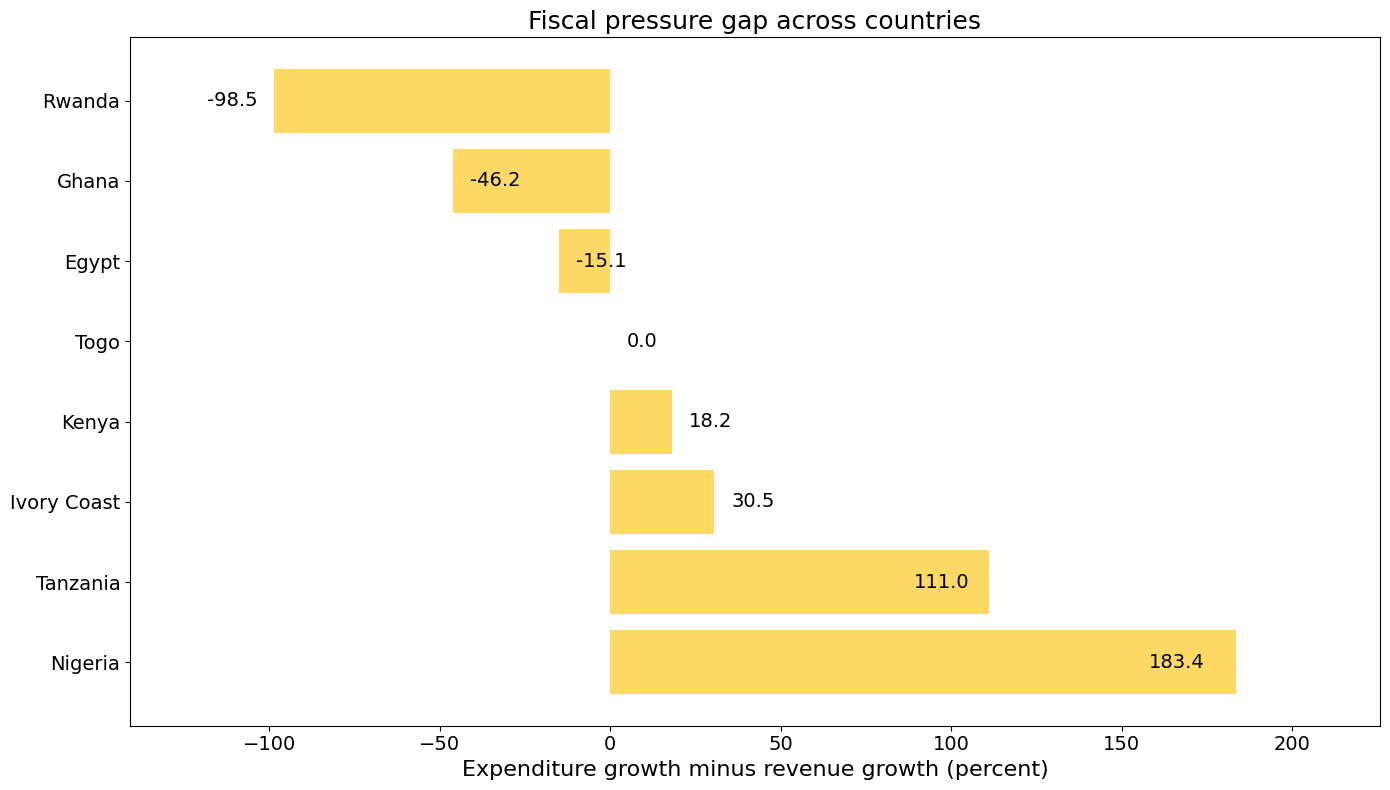

In [ ]:
import matplotlib.pyplot as plt

gap_df = rev_exp_compare.sort_values('exp_minus_rev', ascending=False).copy()
gap_df['gap_rounded'] = gap_df['exp_minus_rev'].round(1)

fig = plt.figure(figsize=(14,8), facecolor='none')
ax = fig.add_subplot(111)
ax.set_facecolor('none')

bars = ax.barh(
    gap_df.index,
    gap_df['gap_rounded'],
    color='#ffd966'
)

for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    label = f"{width:.1f}"

    if abs(width) > 50:
        ax.text(
            width - abs(width) * 0.05,
            y_pos,
            label,
            ha='right',
            va='center',
            fontsize=14,
            color='black'
        )
    else:
        ax.text(
            width + 5,
            y_pos,
            label,
            ha='left',
            va='center',
            fontsize=14,
            color='black'
        )

# -------- FIX FOR CUT EDGES --------
# Calculate safe padding
max_val = max(gap_df['gap_rounded'])
min_val = min(gap_df['gap_rounded'])

# Add padding of 10 percent on both sides
padding = (max_val - min_val) * 0.15

ax.set_xlim(min_val - padding, max_val + padding)

# Increase left margin for negative labels
plt.gcf().subplots_adjust(left=0.28)

# -----------------------------------

ax.set_xlabel(
    'Expenditure growth minus revenue growth (percent)',
    fontsize=16
)
ax.set_title(
    'Fiscal pressure gap across countries',
    fontsize=18
)

ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

ax.grid(False)
plt.tight_layout()

plt.savefig("fiscal_pressure_gap.png", dpi=300, transparent=True, bbox_inches='tight')
plt.savefig("fiscal_pressure_gap.svg", transparent=True, bbox_inches='tight')

plt.show()


/tmp/ipython-input-3538757519.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  end_latest = ir_df.groupby('country').apply(lambda x: x.loc[x['year'].idxmax()])


,rate_2014,rate_latest,pct_change
country,,,
Angola,9.000,19.500,116.667
Nigeria,12.167,25.562,110.103
Egypt,11.708,22.017,88.043
Ghana,18.500,28.333,53.153
Kenya,8.500,12.582,48.021
South Africa,5.625,8.167,45.185
Rwanda,6.708,6.958,3.727
Ivory Coast,6.443,6.449,0.091
Togo,8.787,7.538,-14.207


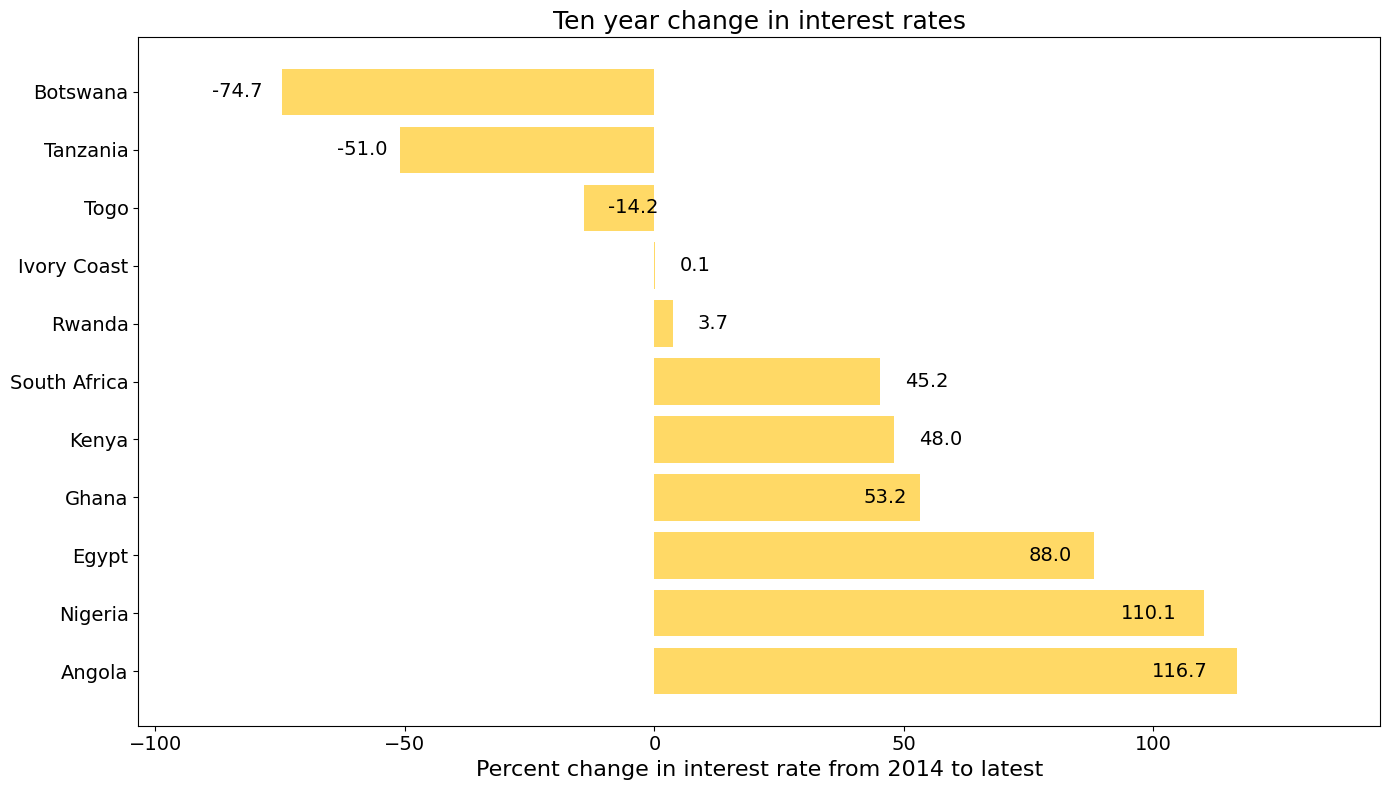

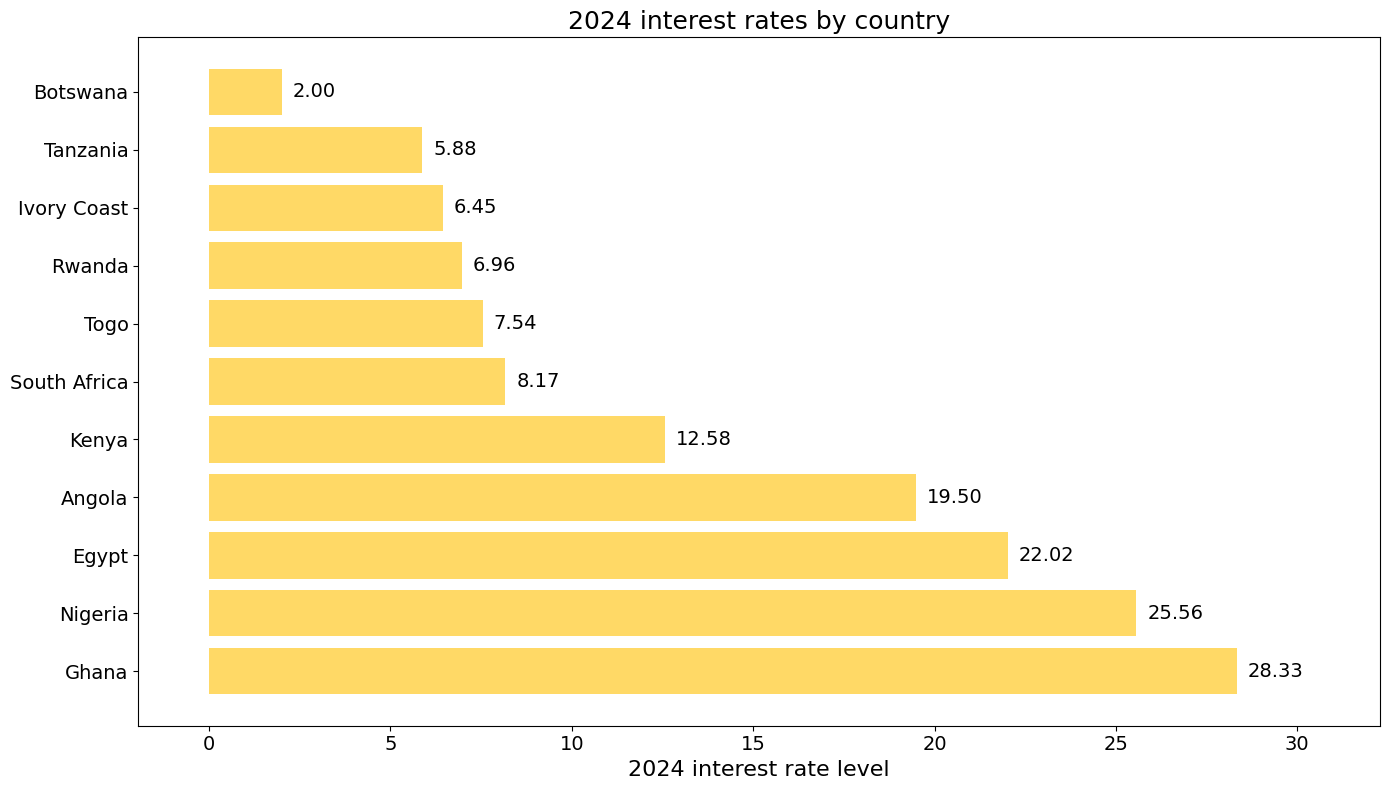

Saved interest_rate_change_and_levels.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np

# ---------- Prepare table ----------
ir_df = analysis_df[analysis_df['indicator'] == 'Interest Rate'][['country','year','amount']].copy()

# get 2014 start and latest per country with safety checks
start_2014 = ir_df[ir_df['year'] == 2014].set_index('country')['amount']
end_latest = ir_df.groupby('country').apply(lambda x: x.loc[x['year'].idxmax()])
end_latest = end_latest.set_index('country')['amount']

ir_change = pd.DataFrame({
    'rate_2014': start_2014,
    'rate_latest': end_latest
}).dropna()

# check for zero or near zero 2014 rates which would create infinite pct changes
ir_change['zero_start'] = (ir_change['rate_2014'].abs() < 1e-9)
if ir_change['zero_start'].any():
    print("Warning: some countries have zero or near zero interest rate in 2014. Inspect raw values before using percent change.\n")
    display(ir_change[ir_change['zero_start']])

# compute percent change safely
ir_change['pct_change'] = np.where(
    ir_change['zero_start'],
    np.nan,
    ((ir_change['rate_latest'] - ir_change['rate_2014']) / ir_change['rate_2014']) * 100
)

ir_change = ir_change.sort_values('pct_change', ascending=False)

# Display summary table
display(ir_change[['rate_2014','rate_latest','pct_change']].round(3))

# ---------- Chart 1: Ten year percent change ----------

pct_df = ir_change.copy()
pct_df['pct_round'] = pct_df['pct_change'].round(1)

fig = plt.figure(figsize=(14,8), facecolor='none')
ax = fig.add_subplot(111)
ax.set_facecolor('none')

bars = ax.barh(pct_df.index, pct_df['pct_round'], color='#ffd966')

for bar in bars:
    w = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    label = f"{w:.1f}" if not np.isnan(w) else "NA"
    if np.isnan(w):
        ax.text(0, y, label, ha='left', va='center', fontsize=14, color='black')
    elif abs(w) > 50:
        ax.text(w - abs(w) * 0.05, y, label, ha='right', va='center', fontsize=14, color='black')
    else:
        ax.text(w + 5, y, label, ha='left', va='center', fontsize=14, color='black')

# safe padding to avoid clipping
max_val = np.nanmax(pct_df['pct_round'].fillna(0))
min_val = np.nanmin(pct_df['pct_round'].fillna(0))
padding = (max_val - min_val) * 0.15 if max_val != min_val else abs(max_val) * 0.15 + 5
ax.set_xlim(min_val - padding, max_val + padding)

# increase left margin for long country names and negative labels
plt.gcf().subplots_adjust(left=0.28)

ax.set_xlabel('Percent change in interest rate from 2014 to latest', fontsize=16)
ax.set_title('Ten year change in interest rates', fontsize=18)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

ax.grid(False)
plt.tight_layout()

plt.savefig("ten_year_interest_rate_change.png", dpi=300, transparent=True, bbox_inches='tight')
plt.savefig("ten_year_interest_rate_change.svg", transparent=True, bbox_inches='tight')
plt.show()

# ---------- Chart 2: Latest interest rate level (2024) ----------

level_df = ir_change[['rate_latest']].sort_values('rate_latest', ascending=False).copy()
level_df['rate_round'] = level_df['rate_latest'].round(2)

fig2 = plt.figure(figsize=(14,8), facecolor='none')
ax2 = fig2.add_subplot(111)
ax2.set_facecolor('none')

bars2 = ax2.barh(level_df.index, level_df['rate_round'], color='#ffd966')

for bar in bars2:
    w = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    label = f"{w:.2f}"
    if abs(w) > 50:
        ax2.text(w - abs(w) * 0.05, y, label, ha='right', va='center', fontsize=14, color='black')
    else:
        ax2.text(w + 0.3, y, label, ha='left', va='center', fontsize=14, color='black')

# padding for level chart
max_val2 = level_df['rate_round'].max()
min_val2 = level_df['rate_round'].min()
pad2 = (max_val2 - min_val2) * 0.15 if max_val2 != min_val2 else max(5, abs(max_val2) * 0.15)
ax2.set_xlim(min_val2 - pad2, max_val2 + pad2)
plt.gcf().subplots_adjust(left=0.28)

ax2.set_xlabel('2024 interest rate level', fontsize=16)
ax2.set_title('2024 interest rates by country', fontsize=18)
ax2.tick_params(axis='y', labelsize=14)
ax2.tick_params(axis='x', labelsize=14)

ax2.grid(False)
plt.tight_layout()

plt.savefig("interest_rate_levels_2024.png", dpi=300, transparent=True, bbox_inches='tight')
plt.savefig("interest_rate_levels_2024.svg", transparent=True, bbox_inches='tight')
plt.show()

# ---------- Save table for records ----------
ir_change.to_csv('interest_rate_change_and_levels.csv', index=True)
print("Saved interest_rate_change_and_levels.csv")


In [ ]:
# build cleaned tables for C3
import pandas as pd

# select Real GDP rows and keep only needed columns
real_gdp = analysis_df[analysis_df['indicator'] == 'Real GDP'][['country','year','amount']].copy()

# get 2014 values per country
real_2014 = real_gdp[real_gdp['year'] == 2014].set_index('country')['amount']

# get latest value per country by using idxmax on year to avoid apply warnings
real_latest = real_gdp.loc[real_gdp.groupby('country')['year'].idxmax()].set_index('country')['amount']

# combine into start end table and compute percent change
real_gdp_change = pd.DataFrame({
    'real_2014': real_2014,
    'real_latest': real_latest
}).dropna()

real_gdp_change['pct_change_real_gdp'] = ((real_gdp_change['real_latest'] - real_gdp_change['real_2014']) / real_gdp_change['real_2014']) * 100

# remove countries with known unit inconsistencies
# these were identified earlier as Kenya and Tanzania
real_gdp_clean = real_gdp_change[~real_gdp_change.index.isin(['Kenya','Tanzania'])].sort_values('pct_change_real_gdp', ascending=False)

# Latest GDP growth rate per country
gdp_growth = analysis_df[analysis_df['indicator'] == 'GDP Growth Rate'][['country','year','amount']].copy()

# pick the latest reported growth rate per country
gdp_growth_latest = gdp_growth.loc[gdp_growth.groupby('country')['year'].idxmax()].set_index('country')['amount'].to_frame(name='latest_gdp_growth')

# display results
print("Real GDP percent change from 2014 to latest, cleaned")
display(real_gdp_clean.round(3))

print("Latest GDP growth rate by country")
display(gdp_growth_latest.round(3))


Real GDP percent change from 2014 to latest, cleaned


,real_2014,real_latest,pct_change_real_gdp
country,,,
Ethiopia,627000.000,2684525.000,328.154
Rwanda,6418.000,18540.000,188.875
Ivory Coast,19804.550,35924.430,81.395
Senegal,9775.039,16491.203,68.707
Togo,2866.640,4731.470,65.053
Ghana,256065.910,394928.510,54.229
Egypt,11050.640,16832.950,52.326
Nigeria,135954.920,161213.060,18.578
South Africa,8726236.220,9318588.000,6.788


Latest GDP growth rate by country


,latest_gdp_growth
country,
Algeria,3.600
Angola,4.500
Egypt,2.310
Ethiopia,8.100
Ghana,5.984
Ivory Coast,6.100
Kenya,4.533
Nigeria,3.374
Rwanda,8.900


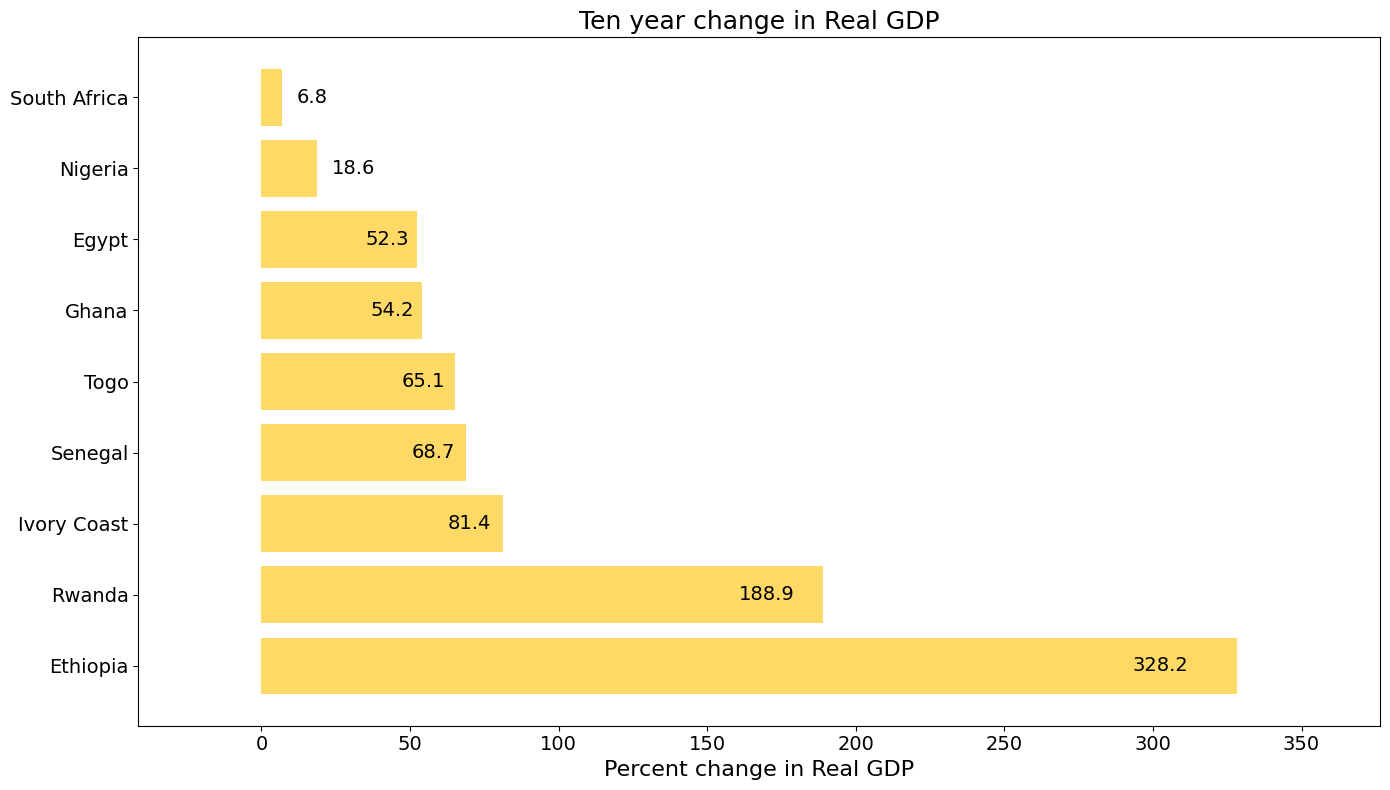

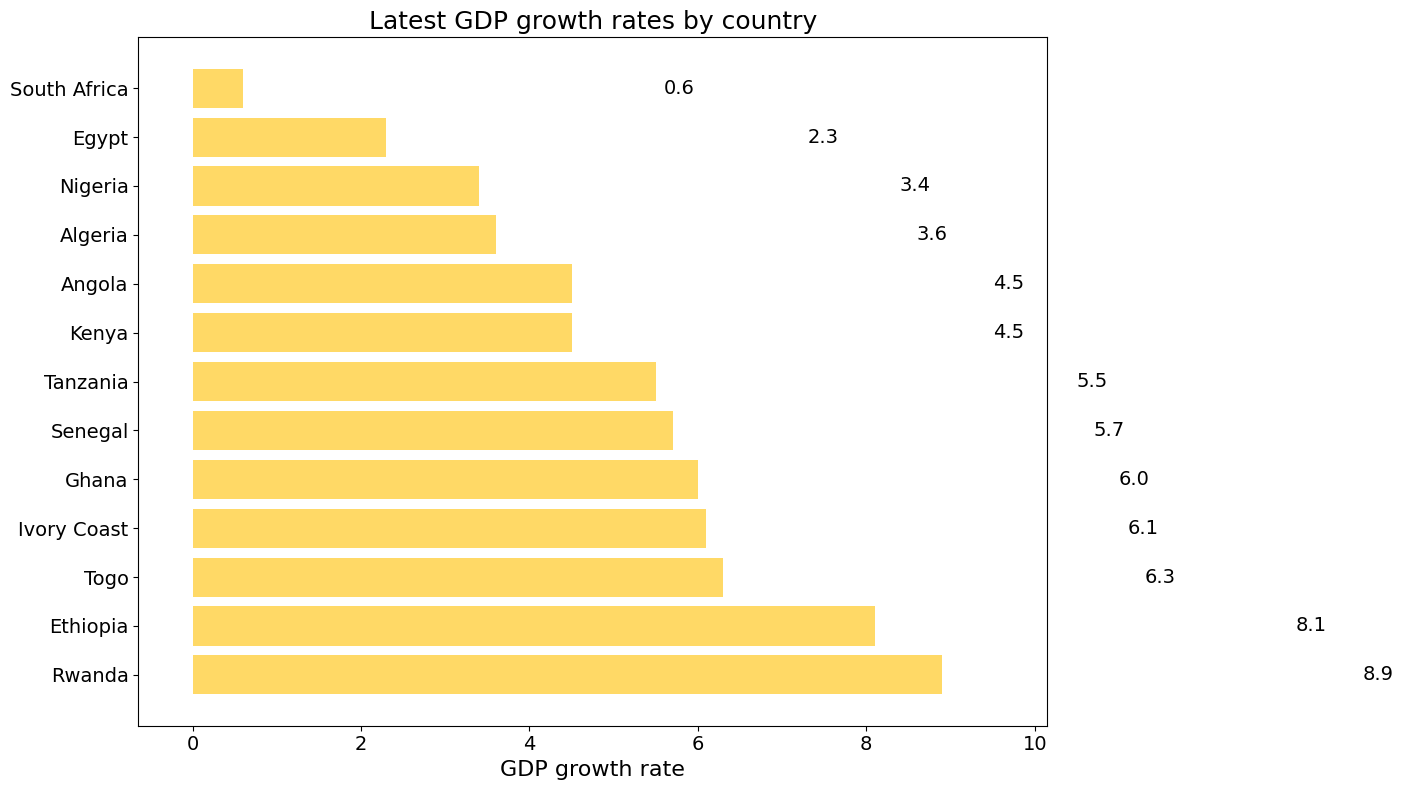

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# updated helper
def draw_barh_clean(df, value_col, title, xlabel, filename):
    df2 = df.copy()
    df2['val_round'] = df2[value_col].round(1)

    fig = plt.figure(figsize=(14,8), facecolor='none')
    ax = fig.add_subplot(111)
    ax.set_facecolor('none')

    bars = ax.barh(df2.index, df2['val_round'], color='#ffd966')

    for bar in bars:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        label = f"{width:.1f}"
        if abs(width) > 50:
            ax.text(width - abs(width) * 0.05, y, label,
                    ha='right', va='center', fontsize=14, color='black')
        else:
            ax.text(width + 5, y, label,
                    ha='left', va='center', fontsize=14, color='black')

    # padding to prevent clipping
    max_val = df2['val_round'].max()
    min_val = df2['val_round'].min()
    padding = (max_val - min_val) * 0.15 if max_val != min_val else max(5, abs(max_val) * 0.15)
    ax.set_xlim(min_val - padding, max_val + padding)

    plt.gcf().subplots_adjust(left=0.28)

    ax.set_title(title, fontsize=18)
    ax.set_xlabel(xlabel, fontsize=16)
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=14)

    ax.grid(False)
    plt.tight_layout()

    plt.savefig(f"{filename}.png", dpi=300, transparent=True, bbox_inches='tight')
    plt.savefig(f"{filename}.svg", transparent=True, bbox_inches='tight')
    plt.show()


# Plot 1: Ten year change in Real GDP
draw_barh_clean(
    real_gdp_clean,
    'pct_change_real_gdp',
    'Ten year change in Real GDP',
    'Percent change in Real GDP',
    'ten_year_real_gdp_change'
)

# Plot 2: Latest GDP growth rates
draw_barh_clean(
    gdp_growth_latest.sort_values('latest_gdp_growth', ascending=False),
    'latest_gdp_growth',
    'Latest GDP growth rates by country',
    'GDP growth rate',
    'latest_gdp_growth_rates'
)


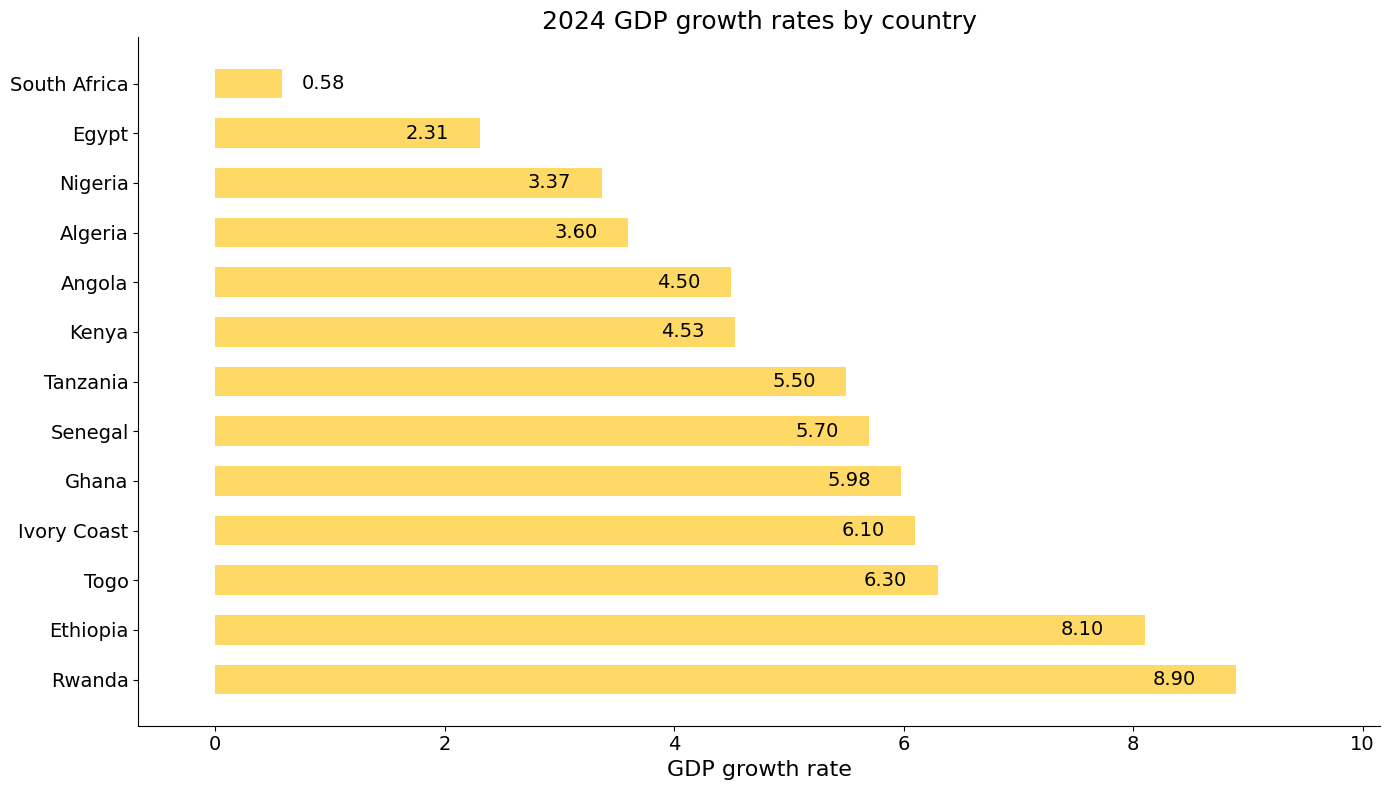

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data sorted from highest to lowest
plot_df = gdp_growth_latest.sort_values('latest_gdp_growth', ascending=False).copy()
plot_df['rate_round'] = plot_df['latest_gdp_growth'].round(2)

# Transparent figure
fig = plt.figure(figsize=(14,8), facecolor='none')
ax = fig.add_subplot(111)
ax.set_facecolor('none')

# Determine axis padding
max_val = plot_df['rate_round'].max()
min_val = plot_df['rate_round'].min()
padding = (max_val - min_val) * 0.15 if max_val != min_val else max(5, abs(max_val) * 0.15)

ax.set_xlim(min_val - padding, max_val + padding)

# Plot bars
bars = ax.barh(plot_df.index, plot_df['rate_round'], color='#ffd966', height=0.6)

# Add data labels with larger font
for bar in bars:
    w = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    label = f"{w:.2f}"

    # label placement rules
    if w > max_val * 0.85:
        ax.text(w - (max_val * 0.04), y, label,
                ha='right', va='center', fontsize=14, color='black')
    elif w > max_val * 0.18:
        ax.text(w - (max_val * 0.03), y, label,
                ha='right', va='center', fontsize=14, color='black')
    else:
        ax.text(w + (max_val * 0.02), y, label,
                ha='left', va='center', fontsize=14, color='black')

# Styling
ax.set_title('2024 GDP growth rates by country', fontsize=18)
ax.set_xlabel('GDP growth rate', fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.grid(False)

# Clear spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.gcf().subplots_adjust(left=0.28)

plt.tight_layout()

# Save crisp copies
plt.savefig("latest_gdp_growth_rates.png", dpi=300, transparent=True, bbox_inches='tight')
plt.savefig("latest_gdp_growth_rates.svg", transparent=True, bbox_inches='tight')

plt.show()


In [ ]:
import pandas as pd

# filter unemployment rate
unemp_df = analysis_df[analysis_df['indicator'] == 'Unemployment Rate'][['country','year','amount']].copy()

# keep only countries with at least one data point after 2014
unemp_df = unemp_df[unemp_df['year'] >= 2014]

# get earliest (2014 or first available after) and latest values
start_vals = unemp_df.sort_values('year').groupby('country').first()
end_vals = unemp_df.sort_values('year').groupby('country').last()

# combine
unemp_change = pd.DataFrame({
    'unemp_start': start_vals['amount'],
    'unemp_latest': end_vals['amount']
})

# calculate percent change
unemp_change['pct_change_unemp'] = ((unemp_change['unemp_latest'] - unemp_change['unemp_start']) / unemp_change['unemp_start']) * 100

# clean formatting
unemp_change = unemp_change.dropna().sort_values('pct_change_unemp', ascending=False)

print("Unemployment change from 2014 to latest:")
display(unemp_change.round(2))


Unemployment change from 2014 to latest:


,unemp_start,unemp_latest,pct_change_unemp
country,,,
Nigeria,7.84,22.56,187.71
South Africa,25.00,32.75,31.00
Botswana,25.00,28.00,12.00
Kenya,5.28,5.38,1.90
Rwanda,15.23,14.93,-1.99
Egypt,13.00,6.50,-50.00


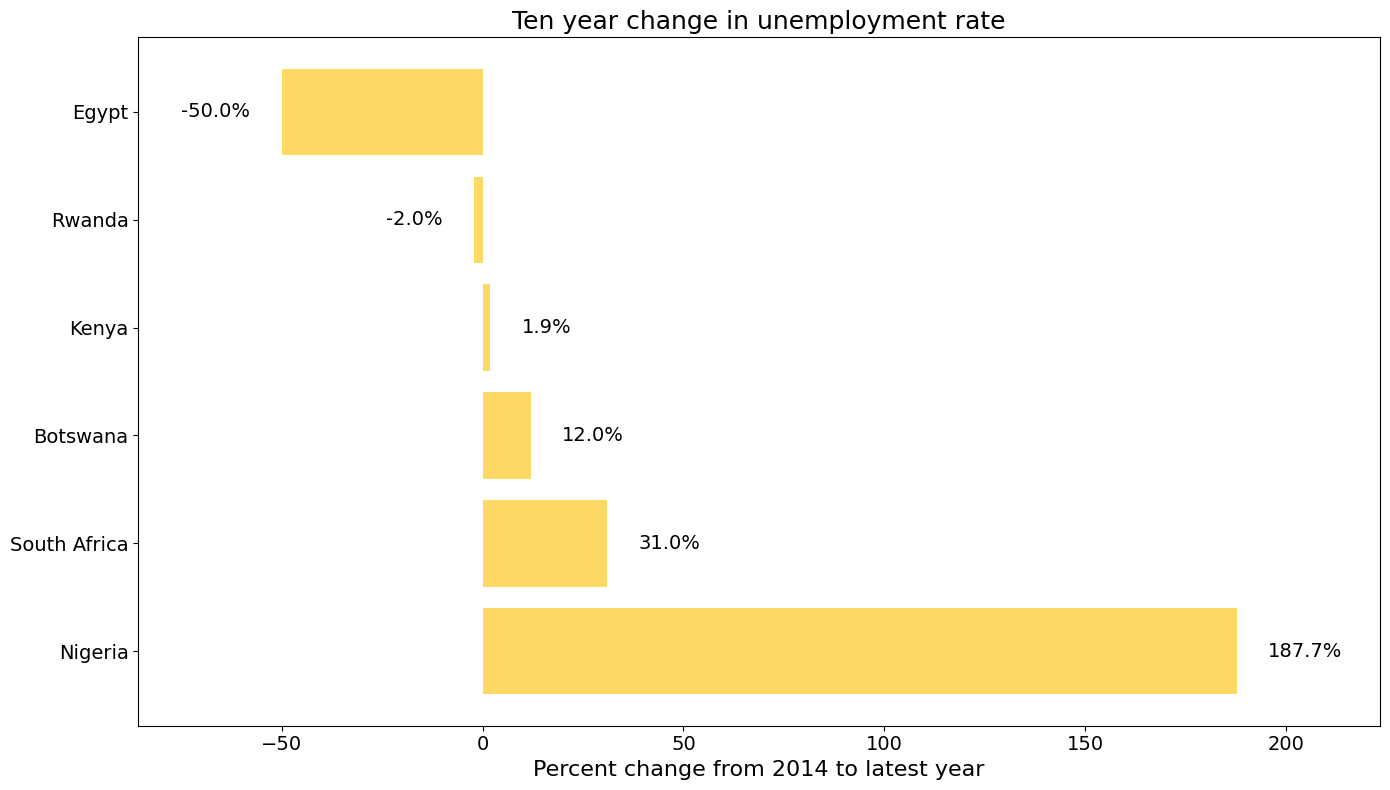

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = unemp_change.copy()
df_plot['pct_round'] = df_plot['pct_change_unemp'].round(1)

fig = plt.figure(figsize=(14,8), facecolor='none')
ax = fig.add_subplot(111)
ax.set_facecolor('none')

bars = ax.barh(df_plot.index, df_plot['pct_round'], color='#ffd966')

# add clear readable labels
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    label = f"{width:.1f}%"

    # dynamic offset based on axis scale
    x_min, x_max = ax.get_xlim()
    offset = (x_max - x_min) * 0.03

    if width < 0:
        ax.text(width - offset, y, label, ha='right', va='center', fontsize=14)
    else:
        ax.text(width + offset, y, label, ha='left', va='center', fontsize=14)

# apply safe padding
vals = df_plot['pct_round'].fillna(0)
max_val = vals.max()
min_val = vals.min()
pad = (max_val - min_val) * 0.15 if max_val != min_val else abs(max_val) * 0.15 + 5
ax.set_xlim(min_val - pad, max_val + pad)

# adjust margins for long names
plt.gcf().subplots_adjust(left=0.28)

# titles and labels
ax.set_title("Ten year change in unemployment rate", fontsize=18)
ax.set_xlabel("Percent change from 2014 to latest year", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

ax.grid(False)
plt.tight_layout()

# crisp export for slides
plt.savefig("ten_year_unemployment_change.png", dpi=300, transparent=True, bbox_inches='tight')
plt.savefig("ten_year_unemployment_change.svg", transparent=True, bbox_inches='tight')

plt.show()
